In [1]:
# =============================================================================
# SECCIÓN 1: IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
import os
from datetime import datetime
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [9]:
# =============================================================================
# SECCIÓN 2: CARGA DEL DATASET - DatasetProyecto
# =============================================================================
import os

# Ruta del dataset
ruta_dataset = 'Datos/DatasetProyecto.csv'

print(f" Buscando dataset en: {ruta_dataset}")

df = None

# Verificar si existe el archivo
if os.path.exists(ruta_dataset):
    # Probar diferentes codificaciones
    codificaciones = ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']
    
    for codif in codificaciones:
        try:
            df = pd.read_csv(ruta_dataset, encoding=codif)
            print(f" Dataset cargado exitosamente (codificación: {codif})")
            break
        except Exception as e:
            print(f" Falló con {codif}: {str(e)[:50]}...")
            continue
else:
    print(f" Error: No se encontró el archivo en {ruta_dataset}")
    print(" Archivos en la carpeta Datos:")
    if os.path.exists('Datos'):
        print(os.listdir('Datos'))

# Verificar que df exista antes de continuar
if df is not None:
    print(f"\n Dataset cargado: {df.shape[0]} registros | {df.shape[1]} columnas")
    print("\n Columnas disponibles:")
    print(df.columns.tolist())
    print("\n Primeras filas:")
    df.head()
else:
    print("\n No se pudo cargar el dataset. Verifica la ruta.")

 Buscando dataset en: Datos/DatasetProyecto.csv
 Falló con utf-8: 'utf-8' codec can't decode byte 0xf1 in position 4...
 Dataset cargado exitosamente (codificación: latin-1)

 Dataset cargado: 2000 registros | 6 columnas

 Columnas disponibles:
['IP', 'Fecha', 'Metodo', 'URL', 'Estado', 'Tamaño']

 Primeras filas:


EXPLORACIÓN Y PREPROCESAMIENTO


In [10]:
# =============================================================================
# SECCIÓN 3: EXPLORACIÓN Y PREPROCESAMIENTO INICIAL
# =============================================================================

print(" INFORMACIÓN DEL DATASET")
print("="*50)
print(f"Registros: {df.shape[0]}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nTipos de datos:")
print(df.dtypes)

# Convertir Fecha a datetime
print("\n Convirtiendo fechas...")
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y %H:%M', errors='coerce')

# Verificar que la conversión funcionó
if df['Fecha'].isnull().sum() > 0:
    print(" Hubo errores en algunas fechas, pero continuamos.")
    
# Eliminar filas con fechas inválidas si es necesario
df = df.dropna(subset=['Fecha'])

print(f"\n Preprocesamiento inicial completado. Registros válidos: {df.shape[0]}")
df.head()

 INFORMACIÓN DEL DATASET
Registros: 2000
Columnas: ['IP', 'Fecha', 'Metodo', 'URL', 'Estado', 'Tamaño']

Tipos de datos:
IP          str
Fecha       str
Metodo      str
URL         str
Estado    int64
Tamaño    int64
dtype: object

 Convirtiendo fechas...

 Preprocesamiento inicial completado. Registros válidos: 2000


,IP,Fecha,Metodo,URL,Estado,Tamaño
0,192.168.164.151,2024-01-01 00:01:00,GET,/products,301,726
1,192.168.155.111,2024-01-01 00:02:00,GET,/robots.txt,200,32483
2,192.168.116.233,2024-01-01 00:03:00,GET,/css/style.css,200,14303
3,192.168.3.171,2024-01-01 00:05:00,HEAD,/products,304,492
4,192.168.200.176,2024-01-01 00:12:00,GET,/sitemap.xml,404,249


 FEATURE ENGINEERING

In [11]:
# =============================================================================
# SECCIÓN 4: FEATURE ENGINEERING
# =============================================================================

print("🔧 Extrayendo características...")

# 1. URL_LENGTH: Longitud de la URL
df['url_length'] = df['URL'].apply(len)

# 2. REQUEST_RATE: Frecuencia de peticiones por IP
ip_counts = df.groupby('IP').size().reset_index(name='request_count')
df = df.merge(ip_counts, on='IP', how='left')

# Calcular tasa (peticiones por hora aproximado)
time_span = (df['Fecha'].max() - df['Fecha'].min()).total_seconds() / 3600
if time_span > 0:
    df['request_rate'] = df['request_count'] / max(time_span, 1)
else:
    df['request_rate'] = df['request_count']

# 3. DURATION: Estimado basado en método y estado
def estimate_duration(row):
    if row['Metodo'] == 'GET': base = 0.5
    elif row['Metodo'] == 'POST': base = 1.5
    else: base = 0.2
    
    if 200 <= row['Estado'] < 300: return base * np.random.uniform(0.8, 1.2)
    elif 300 <= row['Estado'] < 400: return base * 0.5
    else: return base * np.random.uniform(1.5, 3.0)

df['duration'] = df.apply(estimate_duration, axis=1)

# 4. SRC_BYTES y DST_BYTES
df['src_bytes'] = df.apply(lambda row: row['Tamaño'] * 0.1 if row['Metodo'] == 'POST' else row['Tamaño'] * 0.01, axis=1)
df['dst_bytes'] = df['Tamaño']

# 5. NUM_PACKETS
df['num_packets'] = ((df['src_bytes'] + df['dst_bytes']) / 1500).astype(int) + 1

# 6. CODIFICAR Método (GET=0, POST=1, etc.)
from sklearn.preprocessing import LabelEncoder
le_metodo = LabelEncoder()
df['metodo_enc'] = le_metodo.fit_transform(df['Metodo'])

# 7. SERVICE: Inferir tipo de servicio
def infer_service(url):
    url_lower = str(url).lower()
    if 'admin' in url_lower or 'wp-admin' in url_lower: return 0
    elif 'login' in url_lower or 'auth' in url_lower: return 1
    elif 'api' in url_lower: return 2
    elif 'sitemap' in url_lower or 'robots' in url_lower: return 3
    else: return 4

df['service_enc'] = df['URL'].apply(infer_service)

# 8. FLAG: Basado en estado
def infer_flag(status):
    if status == 200: return 0
    elif status in [301, 302, 304]: return 1
    elif status in [401, 403]: return 2
    elif status == 404: return 3
    elif status >= 500: return 4
    else: return 5

df['flag_enc'] = df['Estado'].apply(infer_flag)

# 9. HOUR: Hora del día
df['hour'] = df['Fecha'].dt.hour

print("✅ Feature engineering completado")
df[['IP', 'URL', 'duration', 'request_rate', 'metodo_enc', 'service_enc']].head()

🔧 Extrayendo características...
✅ Feature engineering completado


,IP,URL,duration,request_rate,metodo_enc,service_enc
0,192.168.164.151,/products,0.250000,0.005955,0,4
1,192.168.155.111,/robots.txt,0.599645,0.005955,0,3
2,192.168.116.233,/css/style.css,0.470288,0.011909,0,4
3,192.168.3.171,/products,0.100000,0.005955,1,4
4,192.168.200.176,/sitemap.xml,1.045920,0.005955,0,3


In [ ]:
# =============================================================================
# SECCIÓN 5: CREAR EVALUACIÓN
# =============================================================================

def detectar_anomalo(row):
    score = 0
    url_lower = str(row['URL']).lower()
    
    # Errores 401/403
    if row['Estado'] in [401, 403]:
        score += 3
    
    # Acceso a rutas sensibles con errores
    if any(x in url_lower for x in ['admin', '.env', 'wp-admin', 'config']):
        if row['Estado'] != 200:
            score += 3
    
    # POST inusuales
    if row['Metodo'] == 'POST' and row['Estado'] in [404, 500]:
        score += 2
    
    # Tamaño anormal
    if row['Tamaño'] > 40000 or row['Tamaño'] < 100:
        score += 1
    
    # Errores 500
    if row['Estado'] == 500:
        score += 2
    
    # Muchos requests
    if row['request_rate'] > 10:
        score += 2
    
    # URLs muy largas
    if row['url_length'] > 50:
        score += 1
    
    return 1 if score >= 4 else 0

df['label'] = df.apply(detectar_anomalo, axis=1)

print(" DISTRIBUCIÓN DE CLASES:")
print(f"Normal (0): {(df['label']==0).sum()} registros ({(df['label']==0).mean()*100:.1f}%)")
print(f"Anómalo (1): {(df['label']==1).sum()} registros ({(df['label']==1).mean()*100:.1f}%)")

 DISTRIBUCIÓN DE CLASES:
Normal (0): 1852 registros (92.6%)
Anómalo (1): 148 registros (7.4%)


PREPARAR DATOS PARA EL MODELO

In [13]:
# =============================================================================
# SECCIÓN 6: PREPARACIÓN FINAL DE DATOS
# =============================================================================

# Seleccionar características
features = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'num_packets',
    'url_length',
    'request_rate',
    'Estado',
    'metodo_enc',
    'service_enc',
    'flag_enc',
    'hour'
]

X = df[features].values
y = df['label'].values

# Escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Datos preparados: {X_scaled.shape}")
print(f"Features: {features}")
print(f" Rango: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

Datos preparados: (2000, 11)
Features: ['duration', 'src_bytes', 'dst_bytes', 'num_packets', 'url_length', 'request_rate', 'Estado', 'metodo_enc', 'service_enc', 'flag_enc', 'hour']
 Rango: [-2.87, 5.52]


 ENTRENAR ISOLATION FOREST
 

In [14]:
# =============================================================================
# SECCIÓN 7: ENTRENAMIENTO DEL MODELO
# =============================================================================

from sklearn.ensemble import IsolationForest

contamination_rate = df['label'].mean()
print(f" Tasa de anomalías: {contamination_rate:.3f}")

modelo = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

print("🔄 Entrenando Isolation Forest...")
modelo.fit(X_scaled)

# Predicciones
pred_raw = modelo.predict(X_scaled)
df['pred_isolation'] = np.where(pred_raw == -1, 1, 0)
df['anomaly_score'] = modelo.decision_function(X_scaled)

print("✅ Modelo entrenado exitosamente")
print(f"Predicciones: Normal={df['pred_isolation'].value_counts()[0]} | Anómalo={df['pred_isolation'].value_counts()[1]}")

 Tasa de anomalías: 0.074
🔄 Entrenando Isolation Forest...
✅ Modelo entrenado exitosamente
Predicciones: Normal=1852 | Anómalo=148


EVALUACIÓN DEL MODELO


 RESULTADOS DE LA EVALUACIÓN

 Accuracy: 0.8880 (88.80%)

 Matriz de Confusión:
[[1740  112]
 [ 112   36]]

 Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94      1852
     Anómalo       0.24      0.24      0.24       148

    accuracy                           0.89      2000
   macro avg       0.59      0.59      0.59      2000
weighted avg       0.89      0.89      0.89      2000



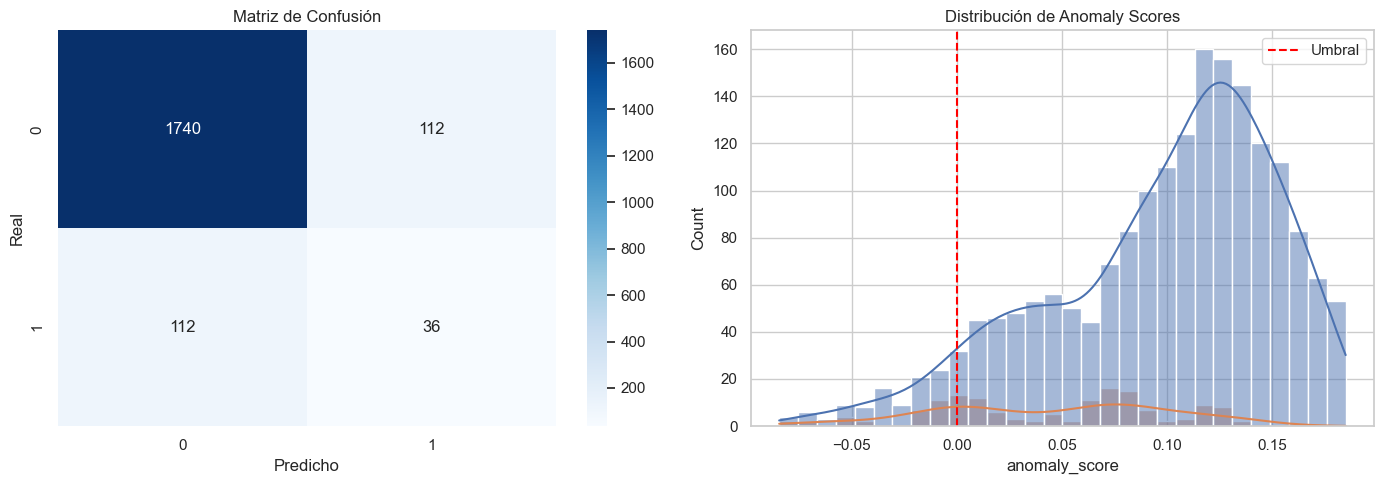

In [15]:
# =============================================================================
# SECCIÓN 8: EVALUACIÓN DEL MODELO
# =============================================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

acc = accuracy_score(y, df['pred_isolation'])
cm = confusion_matrix(y, df['pred_isolation'])
report = classification_report(y, df['pred_isolation'], target_names=['Normal', 'Anómalo'])

print("\n" + "="*60)
print(" RESULTADOS DE LA EVALUACIÓN")
print("="*60)
print(f"\n Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\n Matriz de Confusión:")
print(cm)
print("\n Reporte de Clasificación:")
print(report)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

sns.histplot(data=df, x='anomaly_score', hue='label', bins=30, kde=True, ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', label='Umbral')
axes[1].set_title('Distribución de Anomaly Scores')
axes[1].legend()

plt.tight_layout()
plt.show()

GUARDAR MODELO

In [17]:
# =============================================================================
# SECCIÓN 9: EXPORTAR MODELO
# =============================================================================

import os

# Crear carpeta
os.makedirs('modelo_guardado', exist_ok=True)

# Guardar modelo y escalador
joblib.dump(modelo, 'modelo_guardado/isolation_forest_model.pkl')
joblib.dump(scaler, 'modelo_guardado/scaler.pkl')
joblib.dump(le_metodo, 'modelo_guardado/label_encoder_metodo.pkl')

# Guardar metadata
metadata = {
    'features': features,
    'contamination': contamination_rate,
    'accuracy': acc,
    'total_registros': len(df)
}
joblib.dump(metadata, 'modelo_guardado/metadata.pkl')

print("MODELO GUARDADO EXITOSAMENTE")
print("\n Archivos creados:")
print("  - modelo_guardado/isolation_forest_model.pkl")
print("  - modelo_guardado/scaler.pkl")
print("  - modelo_guardado/label_encoder_metodo.pkl")
print("  - modelo_guardado/metadata.pkl")

MODELO GUARDADO EXITOSAMENTE

 Archivos creados:
  - modelo_guardado/isolation_forest_model.pkl
  - modelo_guardado/scaler.pkl
  - modelo_guardado/label_encoder_metodo.pkl
  - modelo_guardado/metadata.pkl
